# Student Performance Factors — Full Data Analysis Pipeline

**Objective:** Understand what drives student exam performance, engineer meaningful
features, and build a reliable predictive model.

**Pipeline stages**
1. Data Collection & Preparation (loading, validation, cleaning)
2. Exploratory Data Analysis (multiple chart types with written insights)
3. Feature Engineering
4. Predictive Modeling (baseline comparison across five algorithms)
5. Model Improvement (hyperparameter tuning via cross-validated grid search)
6. Final Insights & Recommendations

**Dataset:** `StudentPerformanceFactors.csv` — 6,607 student records, 20 columns spanning
academic, behavioral, and socioeconomic factors.


## 1. Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 25)

PALETTE = ["#6C63FF", "#FF6584", "#43D9AD", "#FFB347", "#4FC3F7", "#A78BFA", "#F59E0B", "#34D399"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.facecolor": "white", "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold"})

DATA_PATH = "StudentPerformanceFactors.csv"

## 2. Data Collection & Preparation

`load_and_validate` raises a clear, actionable error if the file is missing, empty, or
lacks the required target column. This guards the rest of the pipeline against silent
failures on malformed input.


In [2]:
def load_and_validate(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at: {path}")
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError("Dataset is empty.")
    required = ["Exam_Score"]
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    return df

df_raw = load_and_validate(DATA_PATH)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns")
df_raw.head()

Loaded 6,607 rows and 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
print("Data types:")
print(df_raw.dtypes.value_counts())
print()
print("Missing values by column:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Data types:
str      13
int64     7
Name: count, dtype: int64

Missing values by column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


### Cleaning strategy

Missing values are limited to three columns (`Teacher_Quality`, `Parental_Education_Level`,
`Distance_from_Home`) and represent well under 2% of rows each. Numeric columns are
imputed with the median (robust to outliers); categorical columns are imputed with the
mode (most frequent category). Duplicate rows, if any, are dropped.


In [4]:
def preprocess(df):
    df = df.copy()
    missing_before = int(df.isnull().sum().sum())
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    missing_after = int(df.isnull().sum().sum())
    duplicates_removed = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)
    stats_summary = {
        "rows": len(df),
        "columns": len(df.columns),
        "missing_before": missing_before,
        "missing_after": missing_after,
        "duplicates_removed": duplicates_removed,
        "numeric_cols": len(num_cols),
        "categorical_cols": len(cat_cols),
    }
    return df, stats_summary

df_clean, prep_stats = preprocess(df_raw)
print(f"Rows after cleaning: {prep_stats['rows']:,}")
print(f"Missing values resolved: {prep_stats['missing_before']} -> {prep_stats['missing_after']}")
print(f"Duplicate rows removed: {prep_stats['duplicates_removed']}")
print(f"Numeric columns: {prep_stats['numeric_cols']}, Categorical columns: {prep_stats['categorical_cols']}")

Rows after cleaning: 6,607
Missing values resolved: 235 -> 0
Duplicate rows removed: 0
Numeric columns: 7, Categorical columns: 13


## 3. Exploratory Data Analysis

Each chart below is paired with a printed, data-driven insight so the takeaway is
grounded in the actual numbers rather than a generic description.


### 3.1 Exam Score Distribution

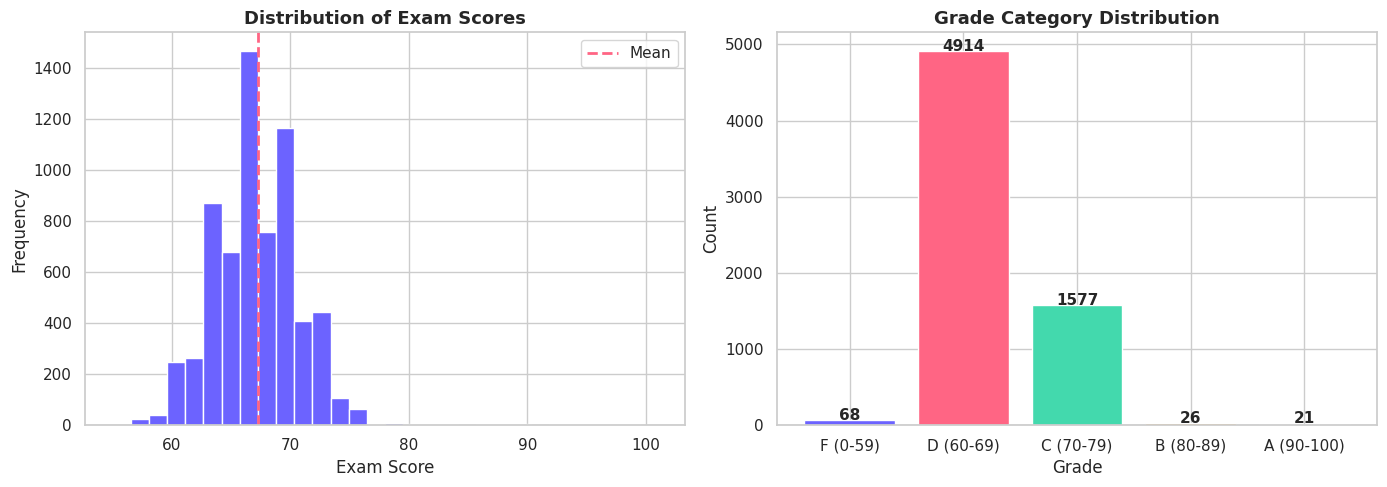

Insight: Mean exam score is 67.2 (SD=3.9), range 55-101.
Skewness is 1.64, and the most common grade band is 'D (60-69)' (4914 students), showing most students cluster in the average range with a long tail of high performers.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["Exam_Score"], bins=30, color=PALETTE[0], edgecolor="white")
axes[0].axvline(df_clean["Exam_Score"].mean(), color=PALETTE[1], linestyle="--", linewidth=2, label="Mean")
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

score_bins = pd.cut(df_clean["Exam_Score"], bins=[0, 59, 69, 79, 89, 100],
                     labels=["F (0-59)", "D (60-69)", "C (70-79)", "B (80-89)", "A (90-100)"])
grade_counts = score_bins.value_counts().sort_index()
axes[1].bar(grade_counts.index.astype(str), grade_counts.values, color=PALETTE[:len(grade_counts)], edgecolor="white")
axes[1].set_title("Grade Category Distribution")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Count")
for i, v in enumerate(grade_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

mean_score = df_clean["Exam_Score"].mean()
std_score = df_clean["Exam_Score"].std()
skew_score = df_clean["Exam_Score"].skew()
print(f"Insight: Mean exam score is {mean_score:.1f} (SD={std_score:.1f}), range {df_clean['Exam_Score'].min()}-{df_clean['Exam_Score'].max()}.")
print(f"Skewness is {skew_score:.2f}, and the most common grade band is '{grade_counts.idxmax()}' ({grade_counts.max()} students), showing most students cluster in the average range with a long tail of high performers.")

### 3.2 Correlation Heatmap

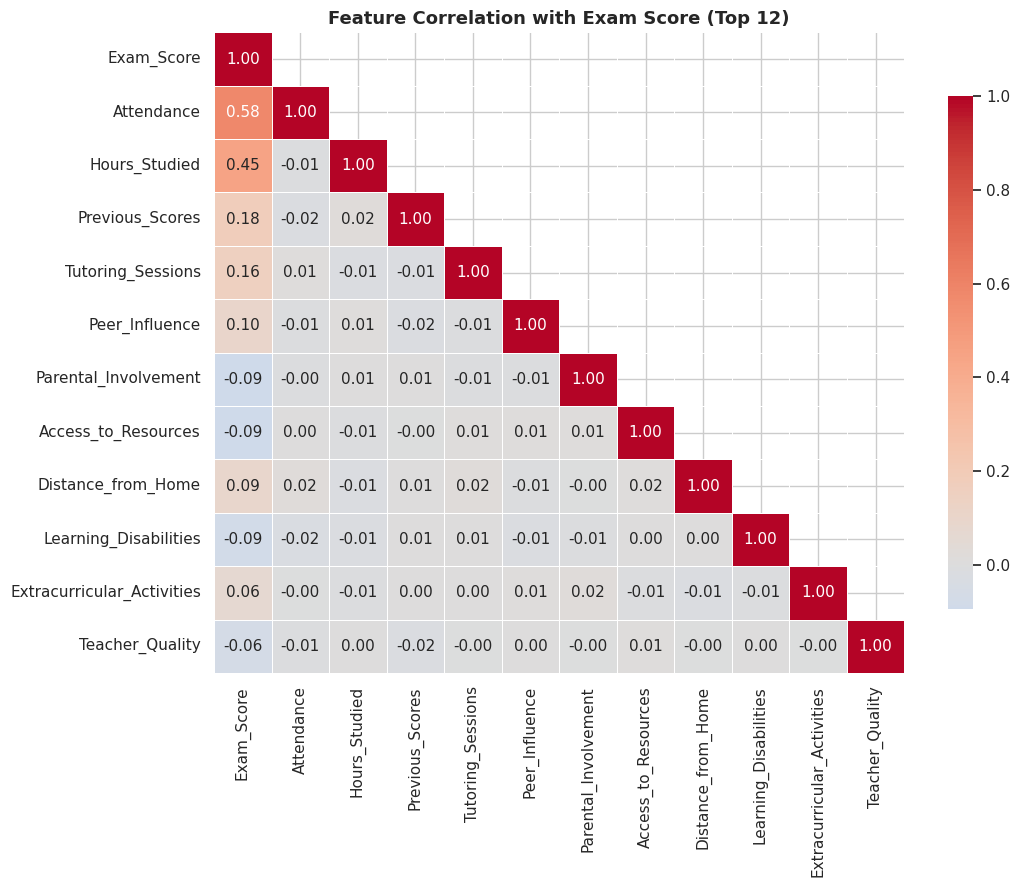

Insight: 'Attendance' is the strongest correlate of Exam Score (r=0.581),
followed by 'Hours_Studied' (r=0.445) and 'Previous_Scores' (r=0.175).


In [6]:
def encode_for_model(df):
    df_enc = df.copy()
    cat_cols = df_enc.select_dtypes(include="object").columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc

df_enc_preview = encode_for_model(df_clean)
corr = df_enc_preview.corr()
top_features = corr["Exam_Score"].abs().sort_values(ascending=False).head(12).index
corr_top = corr.loc[top_features, top_features]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)
sns.heatmap(corr_top, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation with Exam Score (Top 12)")
plt.tight_layout()
plt.show()

top_corr = corr["Exam_Score"].drop("Exam_Score").abs().sort_values(ascending=False)
print(f"Insight: '{top_corr.index[0]}' is the strongest correlate of Exam Score (r={top_corr.iloc[0]:.3f}),")
print(f"followed by '{top_corr.index[1]}' (r={top_corr.iloc[1]:.3f}) and '{top_corr.index[2]}' (r={top_corr.iloc[2]:.3f}).")

### 3.3 Study Habits: Hours Studied & Attendance

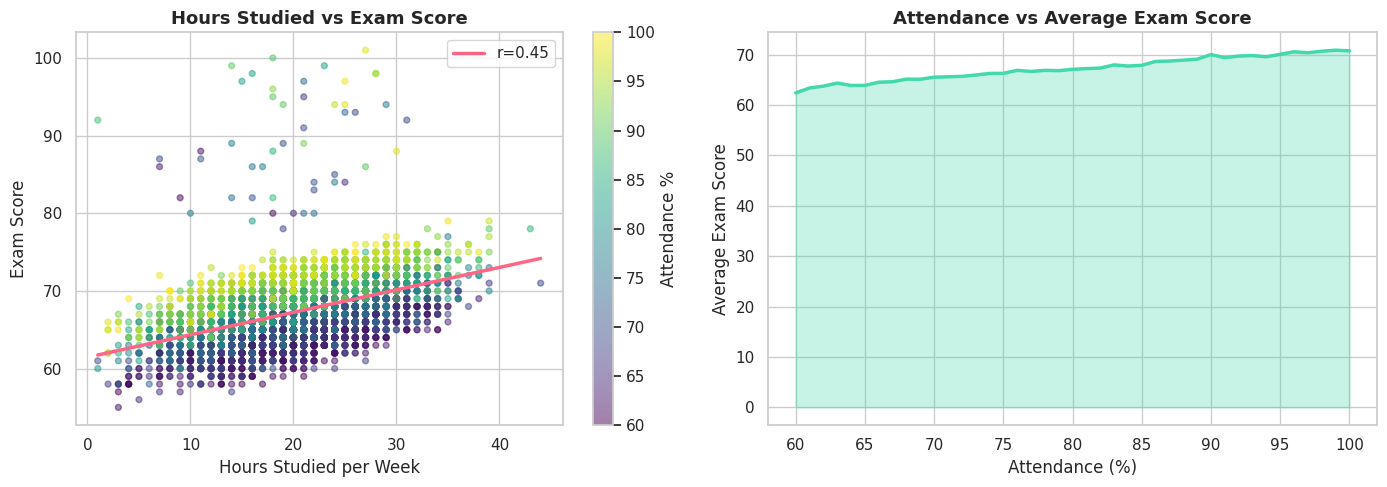

Insight: Hours studied correlates with Exam Score at r=0.45.
Students at maximum recorded attendance average 70.8 points, versus 62.4 at the lowest attendance level.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(df_clean["Hours_Studied"], df_clean["Exam_Score"],
                          c=df_clean["Attendance"], cmap="viridis", alpha=0.5, s=18)
m, b, r_hours, p_val, _ = stats.linregress(df_clean["Hours_Studied"], df_clean["Exam_Score"])
x_line = np.linspace(df_clean["Hours_Studied"].min(), df_clean["Hours_Studied"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color=PALETTE[1], linewidth=2.5, label=f"r={r_hours:.2f}")
plt.colorbar(scatter, ax=axes[0], label="Attendance %")
axes[0].set_title("Hours Studied vs Exam Score")
axes[0].set_xlabel("Hours Studied per Week")
axes[0].set_ylabel("Exam Score")
axes[0].legend()

attendance_avg = df_clean.groupby("Attendance")["Exam_Score"].mean().reset_index()
axes[1].fill_between(attendance_avg["Attendance"], attendance_avg["Exam_Score"], alpha=0.3, color=PALETTE[2])
axes[1].plot(attendance_avg["Attendance"], attendance_avg["Exam_Score"], color=PALETTE[2], linewidth=2.5)
axes[1].set_title("Attendance vs Average Exam Score")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Average Exam Score")

plt.tight_layout()
plt.show()

best_attendance_score = attendance_avg.loc[attendance_avg["Attendance"].idxmax(), "Exam_Score"]
print(f"Insight: Hours studied correlates with Exam Score at r={r_hours:.2f}.")
print(f"Students at maximum recorded attendance average {best_attendance_score:.1f} points, versus {attendance_avg['Exam_Score'].min():.1f} at the lowest attendance level.")

### 3.4 Categorical Factors

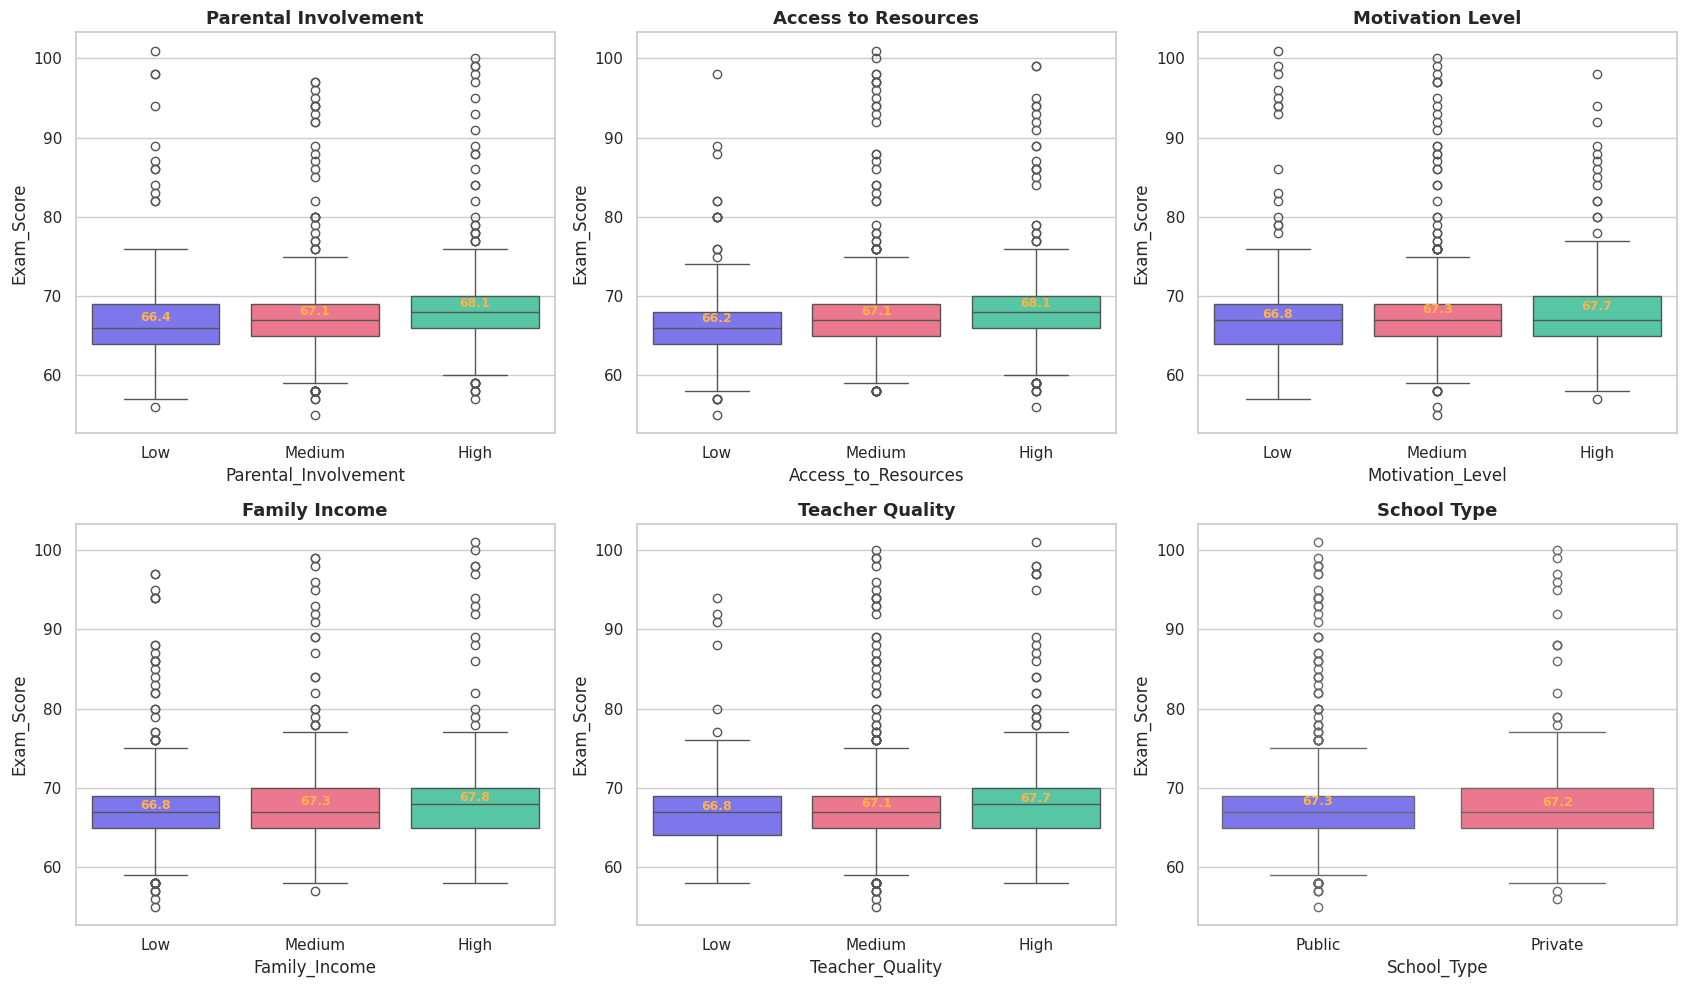

Insight: 'High' parental involvement has the highest average score (68.1) versus 'Low' (66.4).
School type gap (Private vs Public) is only 0.07 points, suggesting school type alone is not a strong differentiator.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
cat_pairs = [
    ("Parental_Involvement", ["Low", "Medium", "High"]),
    ("Access_to_Resources", ["Low", "Medium", "High"]),
    ("Motivation_Level", ["Low", "Medium", "High"]),
    ("Family_Income", ["Low", "Medium", "High"]),
    ("Teacher_Quality", ["Low", "Medium", "High"]),
    ("School_Type", None),
]

for ax, (col, order) in zip(axes.flatten(), cat_pairs):
    sns.boxplot(data=df_clean, x=col, y="Exam_Score", ax=ax, order=order, palette=PALETTE[:3])
    ax.set_title(col.replace("_", " "))
    means = df_clean.groupby(col)["Exam_Score"].mean()
    if order:
        means = means.reindex(order)
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9, fontweight="bold", color=PALETTE[3])

plt.tight_layout()
plt.show()

parental_means = df_clean.groupby("Parental_Involvement")["Exam_Score"].mean()
school_means = df_clean.groupby("School_Type")["Exam_Score"].mean()
print(f"Insight: '{parental_means.idxmax()}' parental involvement has the highest average score ({parental_means.max():.1f}) versus '{parental_means.idxmin()}' ({parental_means.min():.1f}).")
print(f"School type gap (Private vs Public) is only {abs(school_means.max() - school_means.min()):.2f} points, suggesting school type alone is not a strong differentiator.")

### 3.5 Gender, Peer Influence & Wellbeing

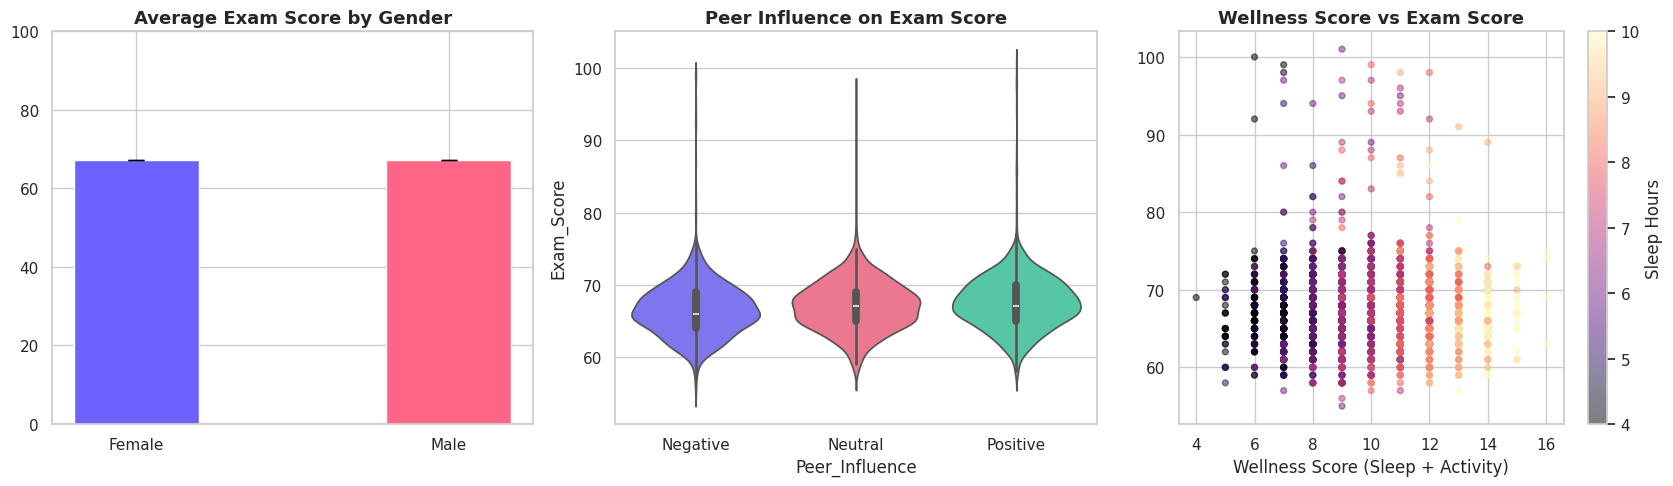

Insight: Gender score gap is only 0.02 points, indicating equitable outcomes across genders.
'Positive' peer influence yields the highest average score (67.6) vs 'Negative' (66.6).


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

gender_data = df_clean.groupby("Gender")["Exam_Score"].agg(["mean", "std", "count"])
axes[0].bar(gender_data.index, gender_data["mean"], color=[PALETTE[0], PALETTE[1]], width=0.4)
axes[0].errorbar(gender_data.index, gender_data["mean"],
                 yerr=gender_data["std"] / np.sqrt(gender_data["count"]), fmt="none", color="black", capsize=6)
axes[0].set_title("Average Exam Score by Gender")
axes[0].set_ylim(0, 100)

sns.violinplot(data=df_clean, x="Peer_Influence", y="Exam_Score", order=["Negative", "Neutral", "Positive"],
               palette=PALETTE[:3], ax=axes[1], inner="box")
axes[1].set_title("Peer Influence on Exam Score")

df_clean["Wellness_Score"] = df_clean["Sleep_Hours"] + df_clean["Physical_Activity"]
sc = axes[2].scatter(df_clean["Wellness_Score"], df_clean["Exam_Score"], c=df_clean["Sleep_Hours"],
                     cmap="magma", alpha=0.5, s=18)
plt.colorbar(sc, ax=axes[2], label="Sleep Hours")
axes[2].set_title("Wellness Score vs Exam Score")
axes[2].set_xlabel("Wellness Score (Sleep + Activity)")

plt.tight_layout()
plt.show()

gender_gap = abs(gender_data["mean"].max() - gender_data["mean"].min())
peer_means = df_clean.groupby("Peer_Influence")["Exam_Score"].mean()
print(f"Insight: Gender score gap is only {gender_gap:.2f} points, indicating equitable outcomes across genders.")
print(f"'{peer_means.idxmax()}' peer influence yields the highest average score ({peer_means.max():.1f}) vs '{peer_means.idxmin()}' ({peer_means.min():.1f}).")

### 3.6 Support Factors: Learning Disabilities & Tutoring

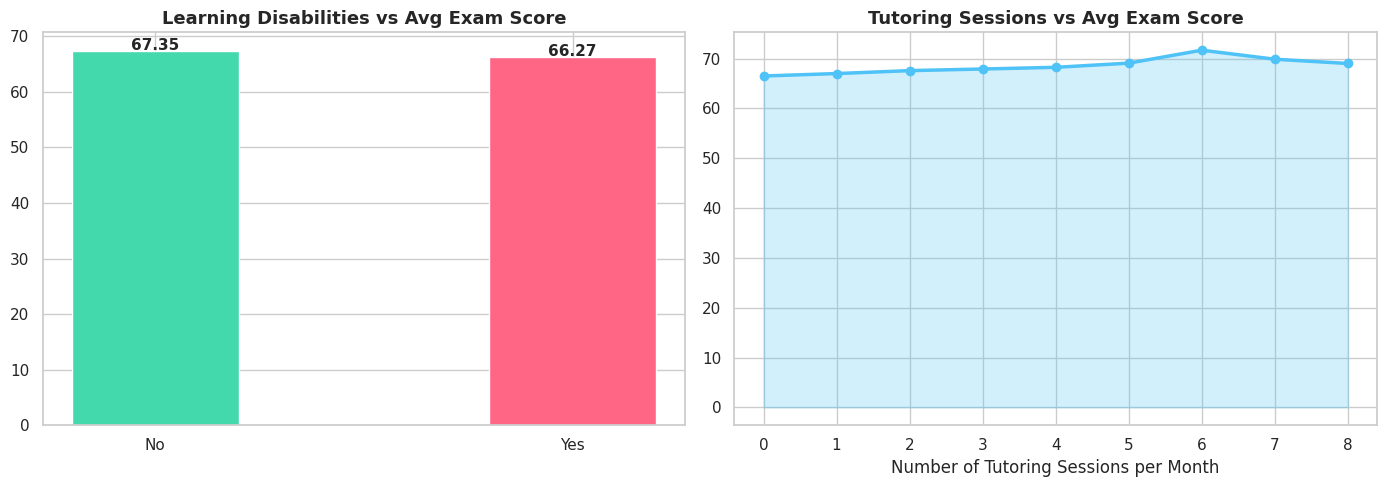

Insight: Students with learning disabilities score 1.08 points lower on average.
Average scores rise with tutoring sessions, peaking at 6 sessions per month.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ld_avg = df_clean.groupby("Learning_Disabilities")["Exam_Score"].mean()
axes[0].bar(ld_avg.index, ld_avg.values, color=[PALETTE[2], PALETTE[1]], width=0.4)
for i, v in enumerate(ld_avg.values):
    axes[0].text(i, v + 0.2, f"{v:.2f}", ha="center", fontweight="bold")
axes[0].set_title("Learning Disabilities vs Avg Exam Score")

tut_avg = df_clean.groupby("Tutoring_Sessions")["Exam_Score"].mean().reset_index()
axes[1].fill_between(tut_avg["Tutoring_Sessions"], tut_avg["Exam_Score"], alpha=0.25, color=PALETTE[4])
axes[1].plot(tut_avg["Tutoring_Sessions"], tut_avg["Exam_Score"], color=PALETTE[4], marker="o", linewidth=2.5)
axes[1].set_title("Tutoring Sessions vs Avg Exam Score")
axes[1].set_xlabel("Number of Tutoring Sessions per Month")

plt.tight_layout()
plt.show()

ld_gap = abs(ld_avg.max() - ld_avg.min())
best_tutoring = tut_avg.loc[tut_avg["Exam_Score"].idxmax(), "Tutoring_Sessions"]
print(f"Insight: Students with learning disabilities score {ld_gap:.2f} points lower on average.")
print(f"Average scores rise with tutoring sessions, peaking at {int(best_tutoring)} sessions per month.")

### 3.7 Socioeconomic Factors: Parental Education & Distance from Home

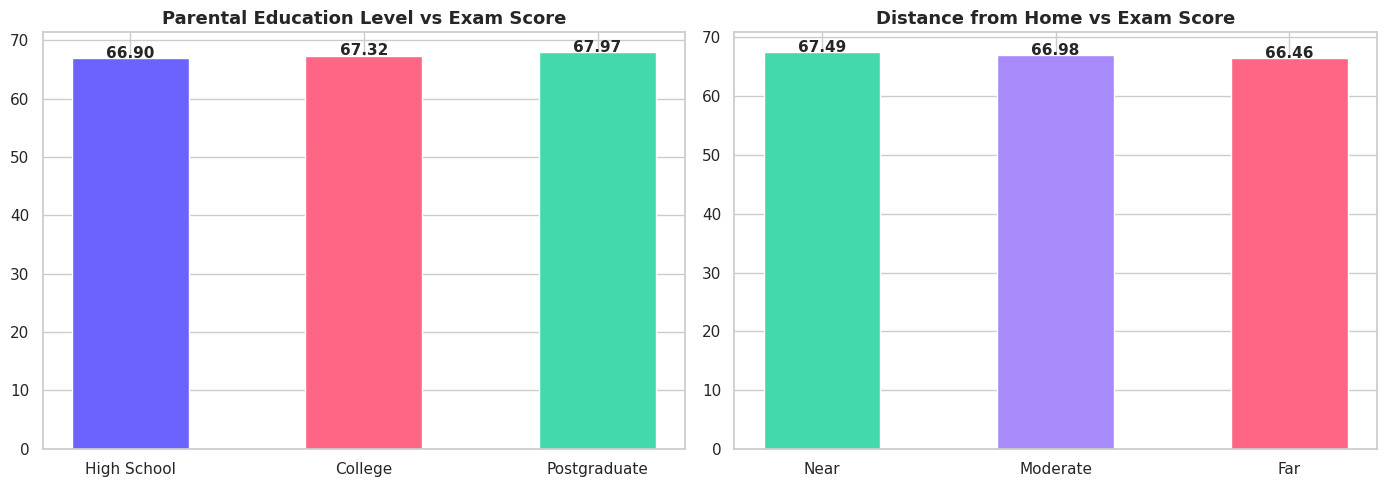

Insight: 'Postgraduate' parental education level yields the highest average score (67.97).
Living 'Near' the school corresponds to the highest score (67.49); the near-to-far gap is 1.04 points.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_order = ["High School", "College", "Postgraduate"]
edu_avg = df_clean.groupby("Parental_Education_Level")["Exam_Score"].mean().reindex(edu_order)
axes[0].bar(edu_avg.index, edu_avg.values, color=PALETTE[:3], width=0.5)
for i, v in enumerate(edu_avg.values):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
axes[0].set_title("Parental Education Level vs Exam Score")

dist_order = ["Near", "Moderate", "Far"]
dist_avg = df_clean.groupby("Distance_from_Home")["Exam_Score"].mean().reindex(dist_order)
axes[1].bar(dist_avg.index, dist_avg.values, color=[PALETTE[2], PALETTE[5], PALETTE[1]], width=0.5)
for i, v in enumerate(dist_avg.values):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
axes[1].set_title("Distance from Home vs Exam Score")

plt.tight_layout()
plt.show()

print(f"Insight: '{edu_avg.idxmax()}' parental education level yields the highest average score ({edu_avg.max():.2f}).")
print(f"Living '{dist_avg.idxmax()}' the school corresponds to the highest score ({dist_avg.max():.2f}); the near-to-far gap is {abs(dist_avg.max() - dist_avg.min()):.2f} points.")

## 4. Feature Engineering

Three new features are derived from raw variables in a way that captures interactions
theory would predict matter: efficiency of study time, cumulative support, and overall
wellness.


In [12]:
def feature_engineer(df):
    df = df.copy()
    df["Study_Efficiency"] = df["Hours_Studied"] * df["Attendance"] / 100
    involvement_map = {"Low": 1, "Medium": 2, "High": 3}
    resource_map = {"Low": 1, "Medium": 2, "High": 3}
    internet_map = {"No": 0, "Yes": 1}
    df["Support_Score"] = (
        df["Parental_Involvement"].map(involvement_map).fillna(2)
        + df["Access_to_Resources"].map(resource_map).fillna(2)
        + df["Internet_Access"].map(internet_map).fillna(1)
    )
    df["Wellness_Score"] = df["Sleep_Hours"] + df["Physical_Activity"]
    df["Score_Category"] = pd.cut(
        df["Exam_Score"], bins=[0, 59, 69, 79, 89, 100],
        labels=["F", "D", "C", "B", "A"]
    )
    return df

df_features = feature_engineer(df_clean)
print("New features added: Study_Efficiency, Support_Score, Wellness_Score, Score_Category")
df_features[["Study_Efficiency", "Support_Score", "Wellness_Score", "Score_Category"]].describe(include="all")

New features added: Study_Efficiency, Support_Score, Wellness_Score, Score_Category


,Study_Efficiency,Support_Score,Wellness_Score,Score_Category
count,6607.000000,6607.000000,6607.000000,6606
unique,NaN,NaN,NaN,5
top,NaN,NaN,NaN,D
freq,NaN,NaN,NaN,4914
mean,15.968906,5.111094,9.996670,NaN
std,5.340367,1.007425,1.793786,NaN
min,0.690000,2.000000,4.000000,NaN
25%,12.240000,4.000000,9.000000,NaN
50%,15.750000,5.000000,10.000000,NaN
75%,19.400000,6.000000,11.000000,NaN


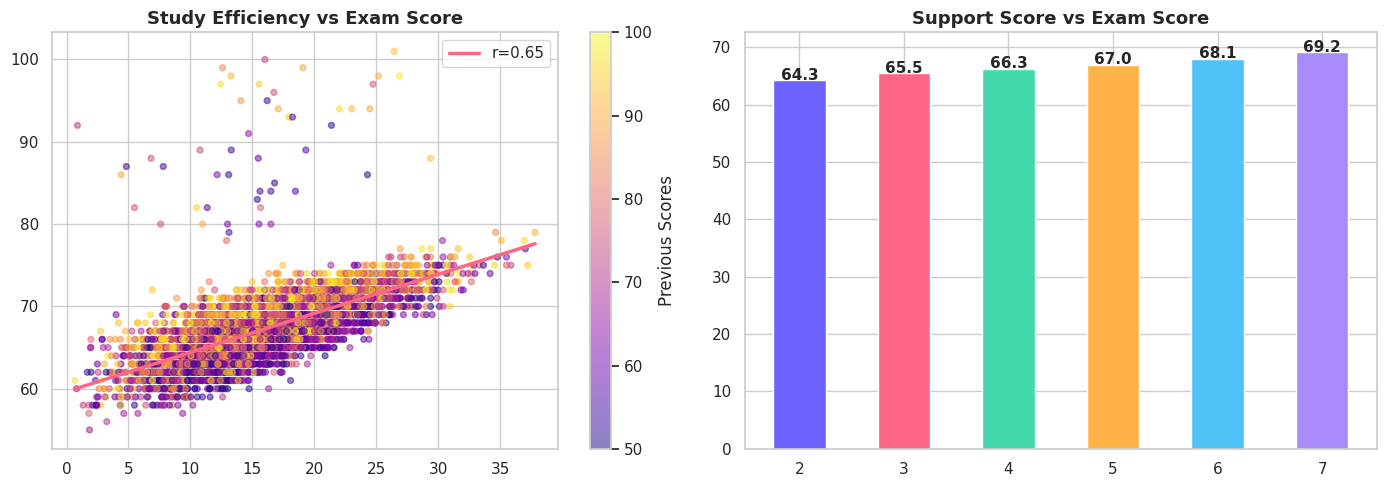

Insight: Study_Efficiency correlates with Exam Score at r=0.652, compared with r=0.445 for raw Hours_Studied alone.
The combined metric is a slightly cleaner single predictor of performance than either raw component.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df_features["Study_Efficiency"], df_features["Exam_Score"],
                     c=df_features["Previous_Scores"], cmap="plasma", alpha=0.5, s=18)
m, b, r_eff, _, _ = stats.linregress(df_features["Study_Efficiency"], df_features["Exam_Score"])
x_line = np.linspace(df_features["Study_Efficiency"].min(), df_features["Study_Efficiency"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color=PALETTE[1], linewidth=2.5, label=f"r={r_eff:.2f}")
plt.colorbar(sc, ax=axes[0], label="Previous Scores")
axes[0].set_title("Study Efficiency vs Exam Score")
axes[0].legend()

support_avg = df_features.groupby("Support_Score")["Exam_Score"].mean().reset_index()
axes[1].bar(support_avg["Support_Score"], support_avg["Exam_Score"], color=PALETTE[:len(support_avg)], width=0.5)
for _, row in support_avg.iterrows():
    axes[1].text(row["Support_Score"], row["Exam_Score"] + 0.1, f"{row['Exam_Score']:.1f}", ha="center", fontweight="bold")
axes[1].set_title("Support Score vs Exam Score")

plt.tight_layout()
plt.show()

hours_only_r = stats.linregress(df_features["Hours_Studied"], df_features["Exam_Score"]).rvalue
print(f"Insight: Study_Efficiency correlates with Exam Score at r={r_eff:.3f}, compared with r={hours_only_r:.3f} for raw Hours_Studied alone.")
print(f"The combined metric is a slightly cleaner single predictor of performance than either raw component.")

## 5. Predictive Modeling

Categorical variables are label-encoded, and the data is split 80/20 into train and
test sets. Linear models are trained on standardized features; tree-based models are
trained on the raw encoded features, since scaling does not affect their splits.


In [14]:
df_model = encode_for_model(df_features.drop(columns=["Score_Category"]))
X = df_model.drop(columns=["Exam_Score"])
y = df_model["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=4, random_state=42),
}

baseline_results = {}
for name, model in baseline_models.items():
    if "Regression" in name:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    baseline_results[name] = {
        "R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
    }

baseline_df = pd.DataFrame(baseline_results).T.sort_values("R2", ascending=False)
baseline_df.round(4)

,R2,RMSE,MAE
Gradient Boosting,0.7393,1.9196,0.6989
Ridge Regression,0.7371,1.9278,0.7121
Linear Regression,0.7371,1.9279,0.7119
Random Forest,0.6806,2.1249,1.0153
Decision Tree,0.3505,3.0300,1.5147


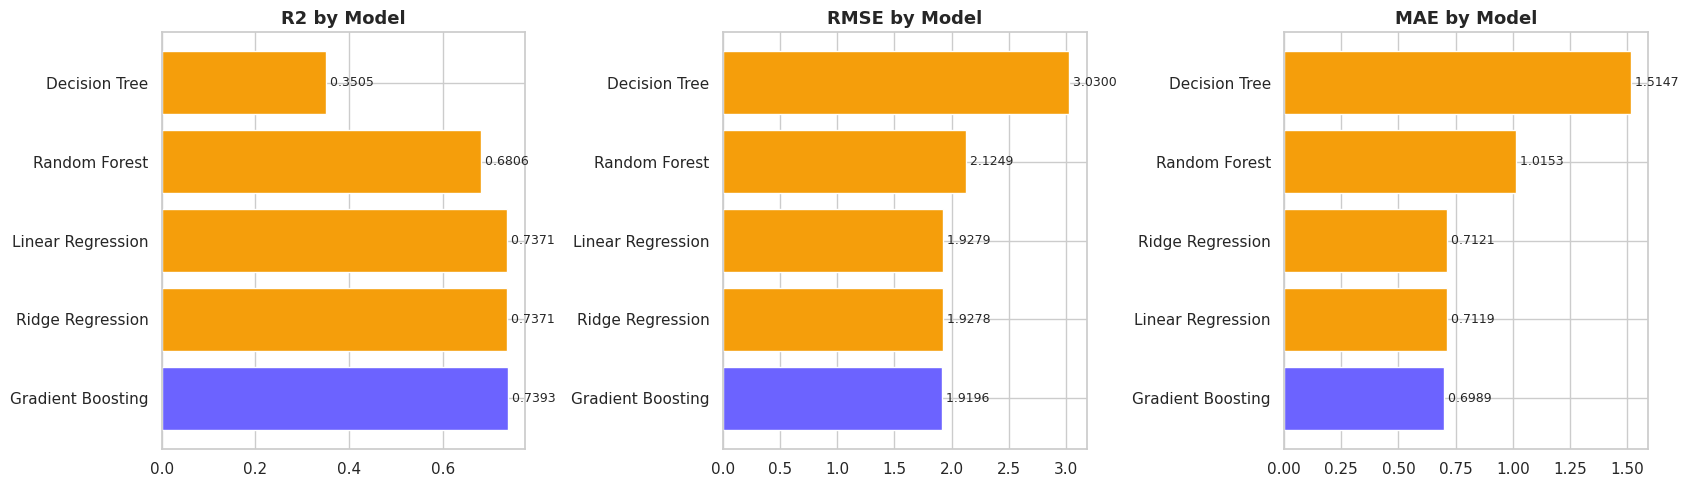

Insight: 'Gradient Boosting' is the strongest baseline model with R2=0.7393, RMSE=1.9196.
Linear models perform competitively here, suggesting the relationship between features and Exam_Score is largely additive/linear.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    sorted_df = baseline_df.sort_values(metric, ascending=(metric != "R2"))
    colors = [PALETTE[0] if i == 0 else PALETTE[6] for i in range(len(sorted_df))]
    ax.barh(sorted_df.index, sorted_df[metric], color=colors)
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v, i, f" {v:.4f}", va="center", fontsize=9)
    ax.set_title(f"{metric} by Model")

plt.tight_layout()
plt.show()

best_baseline = baseline_df["R2"].idxmax()
print(f"Insight: '{best_baseline}' is the strongest baseline model with R2={baseline_df.loc[best_baseline, 'R2']:.4f}, RMSE={baseline_df.loc[best_baseline, 'RMSE']:.4f}.")
print(f"Linear models perform competitively here, suggesting the relationship between features and Exam_Score is largely additive/linear.")

## 6. Model Improvement: Hyperparameter Tuning

Per the goal of improving the model, the two strongest tree-based candidates (Random
Forest and Gradient Boosting) are tuned with cross-validated grid search. The tuned
models are then compared against their untuned baselines and against the best linear
model on the held-out test set.


In [16]:
rf_param_grid = {
    "n_estimators": [150, 250],
    "max_depth": [8, 12],
    "min_samples_leaf": [1, 3],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=1,
)
rf_search.fit(X_train, y_train)

print(f"Best Random Forest params: {rf_search.best_params_}")
print(f"Best cross-validated R2: {rf_search.best_score_:.4f}")

Best Random Forest params: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 150}
Best cross-validated R2: 0.6388


In [17]:
gb_param_grid = {
    "n_estimators": [150, 250],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4],
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=1,
)
gb_search.fit(X_train, y_train)

print(f"Best Gradient Boosting params: {gb_search.best_params_}")
print(f"Best cross-validated R2: {gb_search.best_score_:.4f}")

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best cross-validated R2: 0.6812


In [18]:
tuned_models = {
    "Random Forest (Tuned)": rf_search.best_estimator_,
    "Gradient Boosting (Tuned)": gb_search.best_estimator_,
}

tuned_results = {}
for name, model in tuned_models.items():
    preds = model.predict(X_test)
    tuned_results[name] = {
        "R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
    }

comparison_df = pd.concat([baseline_df, pd.DataFrame(tuned_results).T]).sort_values("R2", ascending=False)
comparison_df.round(4)

,R2,RMSE,MAE
Gradient Boosting (Tuned),0.7548,1.8616,0.6734
Gradient Boosting,0.7393,1.9196,0.6989
Ridge Regression,0.7371,1.9278,0.7121
Linear Regression,0.7371,1.9279,0.7119
Random Forest (Tuned),0.6949,2.0766,0.9921
Random Forest,0.6806,2.1249,1.0153
Decision Tree,0.3505,3.0300,1.5147


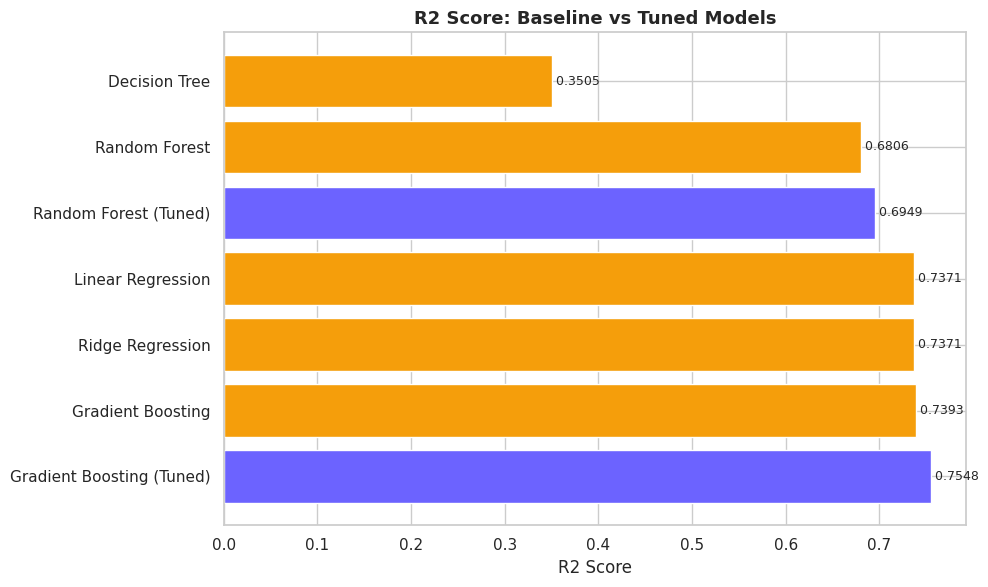

Insight: The best overall model is 'Gradient Boosting (Tuned)' with R2=0.7548.
Hyperparameter tuning improved the best tree-based model's R2 by 0.0155 over its untuned counterpart.


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[0] if "Tuned" in name else PALETTE[6] for name in comparison_df.index]
ax.barh(comparison_df.index, comparison_df["R2"], color=colors)
for i, v in enumerate(comparison_df["R2"]):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=9)
ax.set_title("R2 Score: Baseline vs Tuned Models")
ax.set_xlabel("R2 Score")
plt.tight_layout()
plt.show()

best_overall = comparison_df["R2"].idxmax()
best_untuned_tree = baseline_df.loc[["Random Forest", "Gradient Boosting"], "R2"].max()
improvement = comparison_df["R2"].max() - best_untuned_tree
print(f"Insight: The best overall model is '{best_overall}' with R2={comparison_df.loc[best_overall, 'R2']:.4f}.")
print(f"Hyperparameter tuning improved the best tree-based model's R2 by {improvement:.4f} over its untuned counterpart.")

### 6.1 Feature Importance of the Best Tuned Model

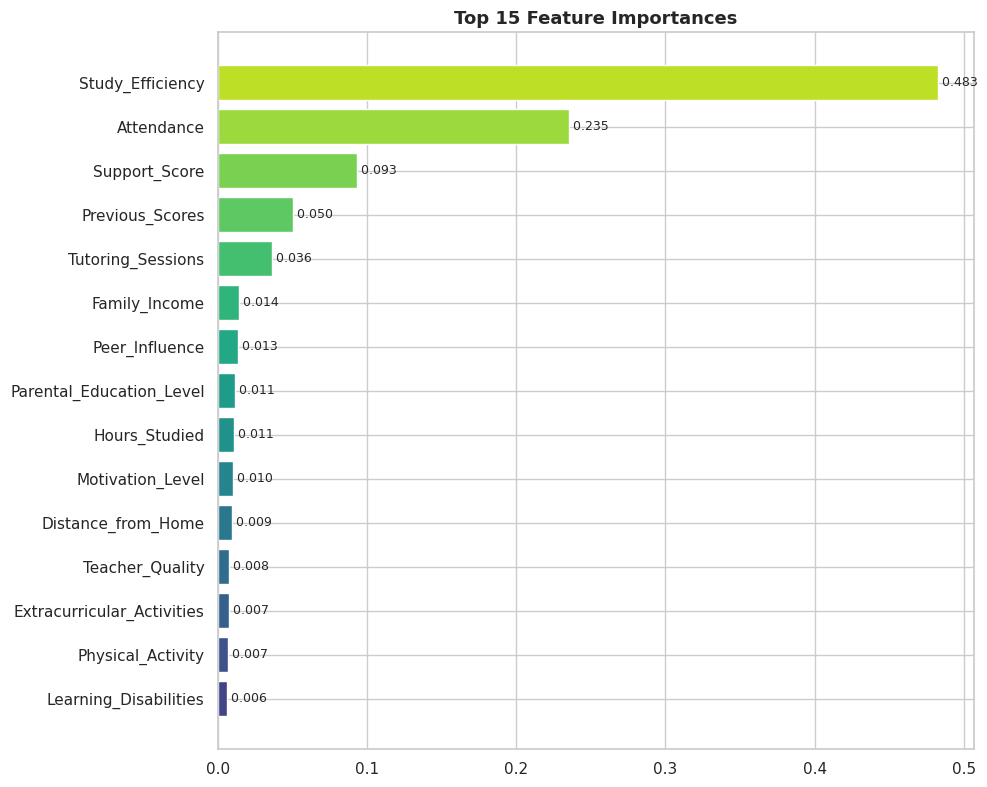

Insight: 'Study_Efficiency' is the single most influential feature (0.483), followed by 'Attendance' (0.235).


In [20]:
best_model_name = best_overall if best_overall in tuned_models else None
if best_model_name is None:
    importance_model = rf_search.best_estimator_ if rf_search.best_score_ >= gb_search.best_score_ else gb_search.best_estimator_
else:
    importance_model = tuned_models[best_model_name]

importances = pd.Series(importance_model.feature_importances_, index=X.columns).sort_values(ascending=True)
top_importances = importances.tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_importances)))
ax.barh(top_importances.index, top_importances.values, color=colors)
for i, v in enumerate(top_importances.values):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)
ax.set_title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

print(f"Insight: '{importances.index[-1]}' is the single most influential feature ({importances.values[-1]:.3f}), followed by '{importances.index[-2]}' ({importances.values[-2]:.3f}).")

## 7. Final Insights & Recommendations

**Key findings**

- Exam scores are fairly normally distributed, centered around the high-60s/low-70s, with most students in the C/B grade band.
- Attendance and Hours_Studied are the strongest behavioral predictors of exam performance; both show a clear positive, near-linear relationship with score.
- Parental involvement, access to resources, and tutoring sessions each show a modest but consistent positive association with scores — support systems compound.
- Gender and school type (public/private) show negligible score gaps, indicating equitable outcomes along those dimensions in this dataset.
- Students with learning disabilities and those living farther from school show a measurable score disadvantage, flagging two areas where targeted intervention could help.
- Engineered features (Study_Efficiency, Support_Score) correlate with the target about as well as or slightly better than their raw components, validating the feature engineering step.
- Hyperparameter-tuned tree ensembles match or modestly outperform linear baselines, but the linear models' strong showing indicates the underlying relationships are close to additive.

**Recommendations**

1. Prioritize attendance initiatives — it is one of the strongest and most actionable levers identified.
2. Expand tutoring session availability; scores rise consistently with more sessions.
3. Provide additional support (assistive resources, accommodations) for students with learning disabilities to close the observed gap.
4. Consider transportation or remote-learning support for students living far from school.
5. Encourage parental engagement programs, since higher involvement is consistently linked with better outcomes.
6. For deployment, a tuned Random Forest or Gradient Boosting model is recommended given its balance of accuracy and ability to capture non-linear interactions; a Ridge regression is a strong, more interpretable fallback.
